<a href="https://colab.research.google.com/github/miokobayashii/Lec2026/blob/main/models/SIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

基本再生産数 (R0) = 3.00


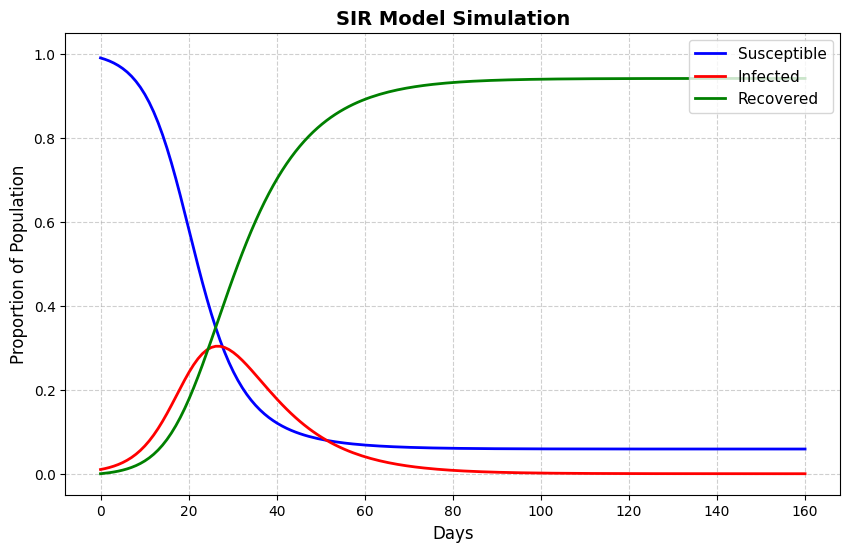

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. SIRモデルの微分方程式の定義
def sir_model(y, t, beta, gamma):
    S, I, R = y

    # 微分方程式
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I

    return [dSdt, dIdt, dRdt]

# 2. 初期状態とパラメータの設定
# 全人口に対する割合（0.0 〜 1.0）で定義
S0 = 0.99  # 未感染者の初期割合（99%）
I0 = 0.01  # 感染者の初期割合（1%）
R0 = 0.00  # 回復者・隔離者の初期割合（0%）
y0 = [S0, I0, R0]

# パラメータ（感染力と回復力）
beta = 0.3    # 感染率 (Transmission rate)
gamma = 0.1   # 回復率 (Recovery rate)

# 基本再生産数 (R0) の計算と表示
R_zero = beta / gamma
print(f"基本再生産数 (R0) = {R_zero:.2f}")

# 3. 時間軸の設定（0日から160日まで）
t = np.linspace(0, 160, 160)

# 4. 微分方程式の数値計算（SciPyのodeintを使用）
solution = odeint(sir_model, y0, t, args=(beta, gamma))
S, I, R = solution.T

# 5. 結果の可視化
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(t, S, label='Susceptible', color='blue', lw=2)
plt.plot(t, I, label='Infected', color='red', lw=2)
plt.plot(t, R, label='Recovered', color='green', lw=2)

# グラフの装飾
plt.title('SIR Model Simulation', fontsize=14, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Proportion of Population', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')
plt.ylim(-0.05, 1.05)

# 表示
plt.show()